Import Libraries

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


## Preprocessing

Load Dataset

In [2]:
df = pd.read_csv("online_retail_II.csv")


Data Preview before cleaning

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Data Cleaning 

In [4]:
df.columns = df.columns.str.strip()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=False, errors="coerce")

df = df[~df["Invoice"].astype(str).str.strip().str.upper().str.startswith("C")]

df = df.dropna(subset=["Customer ID"])

df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

df = df[df["Country"] == "United Kingdom"]

df["Description"] = df["Description"].astype(str).str.strip().str.upper()
df["StockCode"]   = df["StockCode"].astype(str).str.strip()
df["Revenue"]     = df["Quantity"] * df["Price"]

### Summary Statistics

In [5]:

total_inv = df["Invoice"].nunique()
uniq_cust = df["Customer ID"].nunique()
uniq_prod = df["StockCode"].nunique()
d_min, d_max = df["InvoiceDate"].min(), df["InvoiceDate"].max()
avg_basket = df.groupby("Invoice")["StockCode"].nunique().mean()

print(f"\n  Total invoices   : {total_inv:,}")
print(f"  Unique customers : {uniq_cust:,}")
print(f"  Unique products  : {uniq_prod:,}")
print(f"  Date range       : {d_min.date()} to {d_max.date()}")
print(f"  Avg basket size  : {avg_basket:.2f} items/invoice")



  Total invoices   : 33,541
  Unique customers : 5,350
  Unique products  : 4,616
  Date range       : 2009-12-01 to 2011-12-09
  Avg basket size  : 20.57 items/invoice


In [31]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,725250.000000,725250,725250.000000,725250.000000,725250.000000
mean,12.003189,2010-12-31 09:09:18.930548,3.056777,15559.119094,20.300789
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-04 14:27:00,1.250000,14209.000000,4.200000
50%,4.000000,2010-12-02 12:30:30,1.950000,15555.000000,10.200000
75%,12.000000,2011-07-26 11:38:00,3.750000,16938.000000,17.700000
max,80995.000000,2011-12-09 12:49:00,10953.500000,18287.000000,168469.600000
std,140.796321,NaN,25.165512,1593.844795,233.946130


Build Transaction List for pattern mining

In [6]:
transactions  = df.groupby("Invoice")["StockCode"].apply(frozenset).tolist()
N = len(transactions)


In [29]:
print("total transactions:", N  )

total transactions: 33541


## PART A: FP Growth - Co-Purchase Mining

Define FP Node

In [7]:
class FPNode:
    __slots__ = ["item","count","parent","children","link"]
    def __init__(self, item, count, parent):
        self.item=item; self.count=count; self.parent=parent
        self.children={}; self.link=None


Define FP Tree

In [8]:

class FPTree:
    def __init__(self):
        self.root=FPNode(None,0,None); self.headers={}
    def _link(self, node):
        if node.item not in self.headers:
            self.headers[node.item]=node
        else:
            cur=self.headers[node.item]
            while cur.link: cur=cur.link
            cur.link=node
    def insert(self, txn, count=1):
        cur=self.root
        for item in txn:
            if item in cur.children:
                cur.children[item].count+=count
            else:
                n=FPNode(item,count,cur); cur.children[item]=n; self._link(n)
            cur=cur.children[item]


def ascend(node):
    path=[]; node=node.parent
    while node.item is not None: path.append(node.item); node=node.parent
    return path


Mines freq itemsets using FP growth

In [9]:

def mine(tree, order, min_c, prefix, results):
    for item in reversed(order):
        if item not in tree.headers: continue
        new_prefix=prefix|{item}; sup=0; cond_pats=[]
        node=tree.headers[item]
        while node:
            sup+=node.count; path=ascend(node)
            if path: cond_pats.append((path, node.count))
            node=node.link
        if sup<min_c: continue
        results.append((frozenset(new_prefix), sup))
        c_freq=defaultdict(int)
        for path,cnt in cond_pats:
            for i in path: c_freq[i]+=cnt
        c_order=[i for i in order if c_freq.get(i,0)>=min_c]
        if not c_order: continue
        ct=FPTree()
        for path,cnt in cond_pats:
            f=[x for x in c_order if x in path]
            if f: ct.insert(f,cnt)
        mine(ct, c_order, min_c, new_prefix, results)


FP Growth driver function to count item freq, build global ordering and construct tree

In [10]:

def fpgrowth(transactions, min_sup):
    min_c=max(1,int(min_sup*len(transactions)))
    freq=defaultdict(int)
    for t in transactions:
        for i in t: freq[i]+=1
    order=sorted([i for i,c in freq.items() if c>=min_c], key=lambda x:-freq[x])
    tree=FPTree()
    for t in transactions:
        f=[x for x in order if x in t]
        if f: tree.insert(f)
    results=[]
    mine(tree, order, min_c, frozenset(), results)
    return results, freq, min_c


Association Rule Generator

In [11]:

def assoc_rules(fi, transactions, min_conf):
    n=len(transactions)
    sup_map={fs:cnt/n for fs,cnt in fi}
    rules=[]
    for fs,cnt in fi:
        if len(fs)<2: continue
        items=list(fs)
        for r in range(1,len(items)):
            for con_t in combinations(items,r):
                con=frozenset(con_t); ant=fs-con
                if ant in sup_map and sup_map[ant]>0:
                    conf=sup_map[fs]/sup_map[ant]
                    if conf>=min_conf:
                        lift=conf/sup_map[con] if sup_map.get(con,0)>0 else 0
                        rules.append({"antecedents":ant,"consequents":con,
                                      "support":sup_map[fs],"confidence":conf,"lift":lift})
    return pd.DataFrame(rules)



### A0: Hand-trace on 6 invoices


Uses six sample invoices to manually illustrate global ordering and conditional pattern bases for intuitive FP-Growth understanding


In [12]:

inv_df = df.groupby("Invoice")["StockCode"].apply(frozenset).reset_index()
sample6 = inv_df.head(6)
print("\n  A0: FP-Tree Walkthrough — 6 sample invoices")
for _, row in sample6.iterrows():
    print(f"    Invoice {row['Invoice']}: {sorted(row['StockCode'])}")

s6_trans = sample6["StockCode"].tolist()
f6=defaultdict(int)
for t in s6_trans:
    for i in t: f6[i]+=1
s6_order=sorted(f6.items(), key=lambda x:-x[1])

print(f"\n  Global item order desc: {[(i,c) for i,c in s6_order[:8]]}")
top2 = [i for i,_ in s6_order[:2]]
for target in top2:
    print(f"  Conditional Pattern Base for item '{target}':")
    for t in s6_trans:
        if target in t:
            prefix=[i for i,_ in s6_order if i in t and i!=target]
            if prefix: print(f"    Path: {prefix}  (count: 1)")
    print(f"Frequent patterns mined from these prefix paths reveal items that co-occur with '{target}'.\n")



  A0: FP-Tree Walkthrough — 6 sample invoices
    Invoice 489434: ['21232', '21523', '21871', '22041', '22064', '79323P', '79323W', '85048']
    Invoice 489435: ['22195', '22349', '22350', '22353']
    Invoice 489436: ['21181', '21333', '21754', '21755', '21756', '22107', '22109', '22111', '22119', '22142', '22194', '22295', '22296', '35004B', '48173C', '82582', '84596F', '84596L', '84879']
    Invoice 489437: ['10002', '20695', '20703', '20971', '21351', '21352', '21360', '21364', '21912', '21987', '21989', '22111', '22112', '22130', '22143', '22145', '22271', '22272', '22274', '35400', '37370', '84507B', '84970S']
    Invoice 489438: ['20711', '21033', '21100', '21252', '21329', '21410', '21411', '84031A', '84031B', '84032A', '84032B', '84519A', '84519B', '85132A', '85132C', '85183A', '85183B']
    Invoice 489440: ['22349', '22350']

  Global item order desc: [('22349', 2), ('22350', 2), ('22111', 2), ('85048', 1), ('21232', 1), ('21523', 1), ('22064', 1), ('22041', 1)]
  Conditiona


### A1: Full run


Executes FP-Growth on all transactions at 2% minimum support and reports the number of frequent itemsets by size


In [13]:

print("Running FP-Growth (minsup=2%, minconf=50%)")
fi, gfreq, min_c_a = fpgrowth(transactions, 0.02)
print(f"  Min-support count: {min_c_a} invoices  ({0.02*100:.0f}% of {N})")
print(f"  Total frequent itemsets: {len(fi)}")
by_size=defaultdict(int)
for fs,_ in fi: by_size[len(fs)]+=1
for sz in sorted(by_size): print(f"    {sz}-itemsets: {by_size[sz]}")


Running FP-Growth (minsup=2%, minconf=50%)
  Min-support count: 670 invoices  (2% of 33541)
  Total frequent itemsets: 221
    1-itemsets: 193
    2-itemsets: 28



### A2: Rules 


In [14]:

rules_df = assoc_rules(fi, transactions, 0.50)
print(f"\n  Total rules (conf>=50%): {len(rules_df)}")
if not rules_df.empty:
    rules_df = rules_df.sort_values("lift",ascending=False).reset_index(drop=True)
    print("\n  Top 15 Rules by Lift:")
    print(f"  {'Antecedent':<36} {'Consequent':<22} {'Sup':>6} {'Conf':>6} {'Lift':>6}")
    for _,r in rules_df.head(15).iterrows():
        a=", ".join(sorted(r["antecedents"]))[:34]
        c=", ".join(sorted(r["consequents"]))[:20]
        print(f"  {a:<36} {c:<22} {r['support']:>6.3f} {r['confidence']:>6.3f} {r['lift']:>6.2f}")
else:
    print("  No rules at this threshold. Full dataset will produce rules.")



  Total rules (conf>=50%): 14

  Top 15 Rules by Lift:
  Antecedent                           Consequent                Sup   Conf   Lift
  21231                                21232                   0.024  0.722  14.10
  82494L                               82482                   0.029  0.565  11.77
  82482                                82494L                  0.029  0.603  11.77
  21755                                21754                   0.023  0.528  10.02
  21977                                21212                   0.022  0.529   8.39
  84991                                21212                   0.024  0.514   8.15
  20726                                20725                   0.022  0.553   8.11
  22384                                20725                   0.028  0.548   8.05
  20727                                20725                   0.029  0.506   7.43
  85099F                               85099B                  0.027  0.633   7.11
  22386                        


###  A3: Bundle Proposals 

Maps stock codes to product descriptions and prints candidate product bundles derived from high-quality rules


In [15]:

def get_desc(sc):
    m=df[df["StockCode"]==sc]["Description"].mode()
    return m.iloc[0] if len(m) else sc

if not rules_df.empty:
    seen_b=set(); bn=0
    for _,r in rules_df.iterrows():
        bs=frozenset(r["antecedents"])|frozenset(r["consequents"])
        if bs in seen_b or len(bs)<2: continue
        seen_b.add(bs); bn+=1
        codes=list(bs)
        print(f"\n  Bundle {bn}: {codes}")
        for sc in codes: print(f"    {sc}: {get_desc(sc)}")
        print(f"    Rule: {{{', '.join(sorted(r['antecedents']))}}} → {{{', '.join(sorted(r['consequents']))}}}")
        print(f"    Support={r['support']:.3f} | Confidence={r['confidence']:.3f} | Lift={r['lift']:.2f}")
        if bn>=2: break
else:
    print("  Bundles require full dataset (sample too small for 2% support).")



  Bundle 1: ['21231', '21232']
    21231: SWEETHEART CERAMIC TRINKET BOX
    21232: STRAWBERRY CERAMIC TRINKET BOX
    Rule: {21231} → {21232}
    Support=0.024 | Confidence=0.722 | Lift=14.10

  Bundle 2: ['82494L', '82482']
    82494L: WOODEN FRAME ANTIQUE WHITE
    82482: WOODEN PICTURE FRAME WHITE FINISH
    Rule: {82494L} → {82482}
    Support=0.029 | Confidence=0.565 | Lift=11.77


## PART B Class Association Rules: Customer Segmentation

Computes Recency, Frequency, and Monetary metrics per customer, defines thresholds, assigns customer segments, and summarizes segment statistics

In [16]:

snapshot = df["InvoiceDate"].max()
rfm = df.groupby("Customer ID").agg(
    Recency   = ("InvoiceDate", lambda x:(snapshot-x.max()).days),
    Frequency = ("Invoice",     "nunique"),
    Monetary  = ("Revenue",     "sum")
).reset_index()

rq=rfm["Recency"].quantile([.25,.5,.75]).values
fq=rfm["Frequency"].quantile([.25,.5,.75]).values
mq=rfm["Monetary"].quantile([.25,.5,.75]).values

print(f"\n  Recency  quartiles (days): Q1={rq[0]:.0f}  Q2={rq[1]:.0f}  Q3={rq[2]:.0f}")
print(f"  Frequency quartiles (inv): Q1={fq[0]:.0f}   Q2={fq[1]:.0f}   Q3={fq[2]:.0f}")
print(f"  Monetary  quartiles  (£) : Q1={mq[0]:.0f}  Q2={mq[1]:.0f}  Q3={mq[2]:.0f}")

R_REC=rq[1]; R_AR=rq[2]; F_HI=max(fq[2],3); F_LO=2; M_HI=mq[2]; M_LO=mq[0]

print(f"\n  Thresholds:")
print(f"    Champion    : R<{R_REC:.0f}d, F>={F_HI:.0f}, M>=£{M_HI:.0f}")
print(f"    At-Risk     : R>{R_AR:.0f}d, F>={F_LO+1}")
print(f"    One-and-Done: F<={F_LO}, M<£{M_LO:.0f}")

def seg(row):
    r,f,m=row.Recency,row.Frequency,row.Monetary
    if r<R_REC and f>=F_HI and m>=M_HI: return "Champion"
    if r>R_AR  and f>=F_LO+1:           return "At-Risk"
    if f<=F_LO and m<M_LO:              return "One-and-Done"
    return "Other"

rfm["Segment"]=rfm.apply(seg,axis=1)
print(f"\n  Segment counts:")
print(rfm["Segment"].value_counts().to_string())
print(f"\n  Segment summary (mean):")
print(rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean().round(1).to_string())



  Recency  quartiles (days): Q1=25  Q2=98  Q3=381
  Frequency quartiles (inv): Q1=1   Q2=3   Q3=7
  Monetary  quartiles  (£) : Q1=336  Q2=850  Q3=2215

  Thresholds:
    Champion    : R<98d, F>=7, M>=£2215
    At-Risk     : R>381d, F>=3
    One-and-Done: F<=2, M<£336

  Segment counts:
Segment
Other           2856
One-and-Done    1272
Champion         950
At-Risk          272

  Segment summary (mean):
              Recency  Frequency  Monetary
Segment                                   
At-Risk         470.7        4.9    1665.5
Champion         24.1       19.9   10237.3
One-and-Done    354.9        1.2     187.3
Other           167.5        4.1    1507.9



### Plots


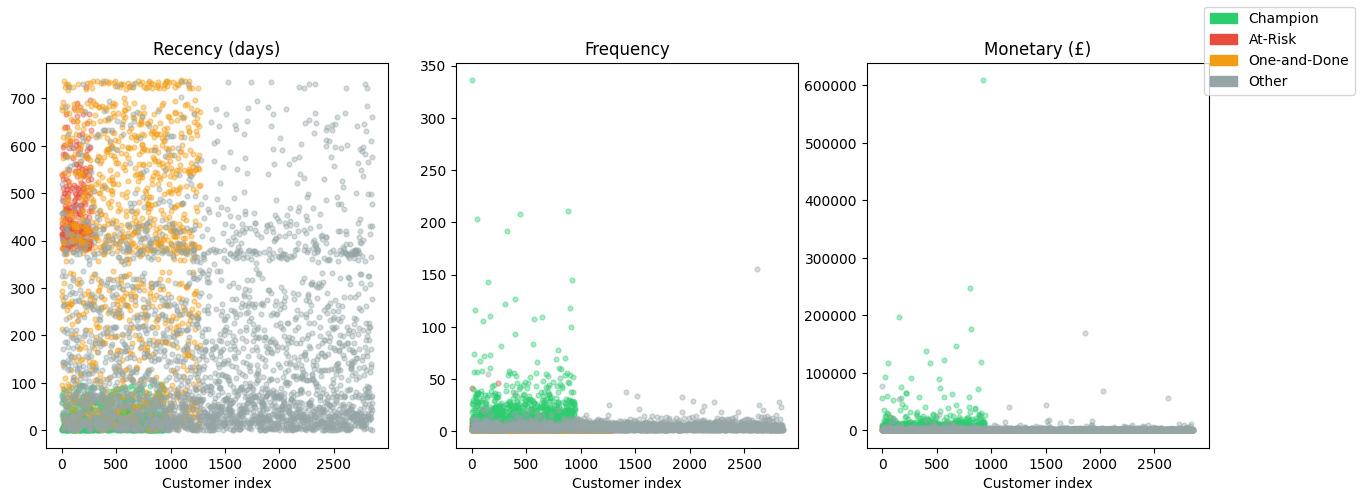

In [17]:

COLS={"Champion":"#2ecc71","At-Risk":"#e74c3c","One-and-Done":"#f39c12","Other":"#95a5a6"}
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,(col,lbl) in zip(axes,[("Recency","Recency (days)"),
                                ("Frequency","Frequency"),
                                ("Monetary","Monetary (£)")]):
    for s,grp in rfm.groupby("Segment"):
        ax.scatter(range(len(grp)),grp[col].values,color=COLS.get(s,"grey"),
                   alpha=0.4,s=12,label=s)
    ax.set_title(lbl); ax.set_xlabel("Customer index")
fig.legend(handles=[mpatches.Patch(color=v,label=k) for k,v in COLS.items()],
           loc="upper right")




###  B1: CARs 


In [18]:

print("\n Class Association Rules (minsup=1%, minconf=55%)")
df_s = df.merge(rfm[["Customer ID","Segment"]],"left","Customer ID")
inv_seg = (df_s.groupby("Invoice")
               .agg(items=("StockCode",lambda x:frozenset(x)),
                    segment=("Segment","first"))
               .reset_index())

car_results={}
for seg_label in ["Champion","At-Risk","One-and-Done"]:
    sub=inv_seg[inv_seg["segment"]==seg_label]
    if len(sub)<5:
        print(f"    {seg_label}: only {len(sub)} invoices — skipped"); continue
    st=sub["items"].tolist()
    fi2,_,_=fpgrowth(st,0.01)
    if not fi2:
        print(f"    {seg_label}: no itemsets at 1%"); continue
    r2=assoc_rules(fi2,st,0.55)
    if r2.empty:
        print(f"    {seg_label}: no rules at 55% conf"); car_results[seg_label]=r2; continue
    r2=r2.sort_values("confidence",ascending=False).reset_index(drop=True)
    car_results[seg_label]=r2
    print(f"\n   {seg_label} ({len(sub)} invoices) ")
    print(f"  {'Antecedent':<35} {'Class':<14} {'Sup':>8} {'Conf':>10}")
    for _,row in r2.head(5).iterrows():
        a=", ".join(sorted(row["antecedents"]))[:33]
        ant_str = "{" + a + "}"
        print(f"  {ant_str:<35} {seg_label:<14} {row['support']:>8.3f} {row['confidence']:>10.3f}")



 Class Association Rules (minsup=1%, minconf=55%)

   Champion (18948 invoices) 
  Antecedent                          Class               Sup       Conf
  {22746}                             Champion          0.011      0.892
  {22698, 22699}                      Champion          0.016      0.884
  {22423, 22698}                      Champion          0.011      0.872
  {22423, 22698}                      Champion          0.011      0.868
  {22697, 22698}                      Champion          0.016      0.866

   At-Risk (1329 invoices) 
  Antecedent                          Class               Sup       Conf
  {21900, 21901}                      At-Risk           0.011      1.000
  {21157, 21535}                      At-Risk           0.010      1.000
  {21527, 21531, 48185}               At-Risk           0.011      1.000
  {21231, 22055}                      At-Risk           0.012      1.000
  {21755, 21756}                      At-Risk           0.011      1.000

   One-and-D


### B2: New Customer Prediction 


In [36]:

top3=df["StockCode"].value_counts().head(10).index[:60].tolist()
# print(top3)
#top3 = [20725, 20727, 22383]

new_items=frozenset(top3)
print(f"\n  New order items: {sorted(new_items)}")
for sc in sorted(new_items): print(f"    {sc}: {get_desc(sc)}")

fired=[]
for sl,rdf in car_results.items():
    if rdf.empty: continue
    for _,row in rdf.iterrows():
        if row["antecedents"].issubset(new_items):
            fired.append((sl,row["antecedents"],row["consequents"],
                          row["support"],row["confidence"]))

if fired:
    fired.sort(key=lambda x:-x[4])
    print(f"\n  Fired rules:")
    print(f"  {'Segment':<14} {'Antecedent':<30} {'Conf':>6}")
    for sl,a,c,s,cf in fired[:5]:
        print(f"  {sl:<14} {str(set(a)):<30} {cf:>6.3f}")
    best=fired[0]
    print(f"\n Predicted segment: '{best[0]}'  (confidence {best[4]:.1%})")
else:
    print("  No rules fired on these items (sample too small).")




  New order items: ['20725', '20727', '21034', '21212', '22383', '22423', '47566', '84879', '85099B', '85123A']
    20725: LUNCH BAG RED RETROSPOT
    20727: LUNCH BAG  BLACK SKULL.
    21034: REX CASH+CARRY JUMBO SHOPPER
    21212: PACK OF 72 RETROSPOT CAKE CASES
    22383: LUNCH BAG SUKI  DESIGN
    22423: REGENCY CAKESTAND 3 TIER
    47566: PARTY BUNTING
    84879: ASSORTED COLOUR BIRD ORNAMENT
    85099B: JUMBO BAG RED RETROSPOT
    85123A: WHITE HANGING HEART T-LIGHT HOLDER

  Fired rules:
  Segment        Antecedent                       Conf
  Champion       {'20725', '20727', '22383'}     0.680
  Champion       {'85099B', '20727'}             0.669
  Champion       {'85099B', '22383'}             0.647
  Champion       {'20727', '22383'}              0.636
  Champion       {'20725', '20727', '22383'}     0.634

 Predicted segment: 'Champion'  (confidence 68.0%)


## PART C: Sequential Pattern Mining (GSP)

In [20]:

import argparse, warnings, re

Category dictionary definition

In [21]:

CATS=[
    ("Candles & Home Fragrance",   r"CANDLE|WAX|TEALIGHT|FRAGRANCE|AROMA|DIFFUSER|INCENSE|SCENT"),
    ("Seasonal & Festive",         r"CHRISTMAS|XMAS|EASTER|HALLOWEEN|VALENTINE|ADVENT|TINSEL|BAUBLE|WREATH|SANTA|FESTIV"),
    ("Kitchen & Dining",           r"MUG|CUP|BOWL|PLATE|DISH|SPOON|FORK|KNIFE|KITCHEN|CAKE|BAKING|TEAPOT|JUG|COFFEE|COOKING"),
    ("Storage & Organisation",     r"BOX|TIN|BASKET|CRATE|RACK|SHELF|CHEST|HAMPER|CADDY|TRAY|TRUNK|DRAWER"),
    ("Stationery & Gifting",       r"CARD|NOTEBOOK|PEN|PENCIL|STICKER|WRAP|RIBBON|GIFT|FRAME|SIGN|BANNER|BUNTING|DIARY"),
    ("Toys & Children",            r"TOY|DOLL|GAME|PUZZLE|BALLOON|BABY|CHILD|KID|PLAY|TEDDY"),
    ("Fashion & Accessories",      r"PURSE|WALLET|SCARF|GLOVE|HAT|JEWEL|BRACELET|NECKLACE|RING|EARRING|BROOCH"),
    ("Garden & Outdoor",           r"GARDEN|PLANT|BIRD|OUTDOOR|WATERING|FLOWER|VASE|FLORAL|HERB|SEED"),
    ("Lighting & Electrical",      r"LIGHT|LAMP|LED|LANTERN|FAIRY|BULB|TORCH|ELECTRIC|CANDELABRA"),
    ("Novelty & Decorative",       r"NOVELTY|FIGURE|STATUE|ORNAMENT|DECORATION|DECOR|VINTAGE|RETRO|CERAMIC|TRINKET"),
    ("Pet & Animal",               r"\bCAT\b|\bDOG\b|\bPET\b|RABBIT|MOUSE"),
    ("Bags & Totes",               r"\bBAG\b|POUCH|TOTE|SHOPPER"),
]


Define category map

In [22]:

def map_cat(desc):
    d=str(desc).upper()
    for cat,pat in CATS:
        if re.search(pat,d): return cat
    return "General Homeware"


Apply category mapping

In [23]:

df["Category"]=df["Description"].apply(map_cat)
cov=(df["Category"]!="General Homeware").sum()/len(df)*100
print(f"\n  Category coverage: {cov:.1f}%")
print("\n  Distribution:")
print(df["Category"].value_counts().to_string())



  Category coverage: 75.4%

  Distribution:
Category
General Homeware            178328
Stationery & Gifting        114792
Kitchen & Dining             92127
Storage & Organisation       83891
Novelty & Decorative         54020
Seasonal & Festive           39615
Lighting & Electrical        35932
Bags & Totes                 32301
Garden & Outdoor             27778
Toys & Children              23354
Candles & Home Fragrance     22054
Fashion & Accessories        16980
Pet & Animal                  4078



Build customer event sequences


In [24]:

ev=(df.groupby(["Customer ID","Invoice","InvoiceDate"])["Category"]
      .apply(frozenset).reset_index(name="cats")
      .sort_values(["Customer ID","InvoiceDate"]))
cust_seqs=(ev.groupby("Customer ID")["cats"].apply(list)
             .reset_index(name="sequence"))
print(f"\n  Customer sequences: {len(cust_seqs)}")



  Customer sequences: 5350


Sequence Matching Utilities (helper func)

In [25]:

def is_subseq(pat,seq):
    pi=0
    for ev in seq:
        if pi<len(pat) and pat[pi].issubset(ev): pi+=1
        if pi==len(pat): return True
    return False

def gsp_count(pat,seqs):
    return sum(1 for s in seqs if is_subseq(pat,s))


### C1: GSP Mining on all Customers

In [37]:

def run_gsp(seqs,min_c,max_len=3):
    res={}
    all_cats=set()
    for s in seqs:
        for e in s: all_cats|=e

    f1=[]
    for c in sorted(all_cats):
        sup=gsp_count([frozenset([c])],seqs)
        if sup>=min_c: f1.append(([frozenset([c])],sup))
    f1.sort(key=lambda x:-x[1]); res[1]=f1
    fc=[next(iter(p[0])) for p,_ in f1]

    f2=[]; seen2=set()
    for c1 in fc:
        for c2 in fc:
            k=(c1,c2)
            if k in seen2: continue
            seen2.add(k)
            pat=[frozenset([c1]),frozenset([c2])]
            sup=gsp_count(pat,seqs)
            if sup>=min_c: f2.append((pat,sup))
    f2.sort(key=lambda x:-x[1]); res[2]=f2

    if max_len>=3:
        f3=[]; seen3=set()
        for p2,_ in f2:
            for c in fc:
                pat=p2+[frozenset([c])]
                k=tuple(tuple(sorted(e)) for e in pat)
                if k in seen3: continue
                seen3.add(k)
                sup=gsp_count(pat,seqs)
                if sup>=min_c: f3.append((pat,sup))
        f3.sort(key=lambda x:-x[1]); res[3]=f3
    return res

seqs_all=cust_seqs["sequence"].tolist()
NA=len(seqs_all)
msc=max(1,int(0.005*NA))
print(f"\n  GSP minsup=0.5% → min {msc} customers (N={NA})")
print("  Running GSP ...")
gsp_all=run_gsp(seqs_all,msc)

print("\n  Frequent sequence counts:")
for l in [1,2,3]: print(f"    Length-{l}: {len(gsp_all.get(l,[]))}")

print("\n  Top 10 Frequent Length-2 Sequences:")
print(f"  {'Sequence':<55} {'Count':>6}  {'%':>5}  Interpretation")

for pat,sup in gsp_all.get(2,[])[:10]:
    c1=next(iter(pat[0])); c2=next(iter(pat[1]))
    s=f"[{c1}] → [{c2}]"; pct=sup/NA*100
    interp=f"Customers who bought {c1[:20]} then {c2[:20]}"
    print(f"  {s:<55} {sup:>6}  {pct:>4.1f}%  {interp[:45]}")



  GSP minsup=0.5% → min 26 customers (N=5350)
  Running GSP ...

  Frequent sequence counts:
    Length-1: 13
    Length-2: 169
    Length-3: 2197

  Top 10 Frequent Length-2 Sequences:
  Sequence                                                 Count      %  Interpretation
  [General Homeware] → [General Homeware]                   3528  65.9%  Customers who bought General Homeware then Ge
  [Storage & Organisation] → [General Homeware]             3226  60.3%  Customers who bought Storage & Organisati the
  [Stationery & Gifting] → [General Homeware]               3204  59.9%  Customers who bought Stationery & Gifting the
  [General Homeware] → [Storage & Organisation]             3187  59.6%  Customers who bought General Homeware then St
  [General Homeware] → [Stationery & Gifting]               3183  59.5%  Customers who bought General Homeware then St
  [Kitchen & Dining] → [General Homeware]                   3177  59.4%  Customers who bought Kitchen & Dining then Ge
  [General 


### C2: At-Risk Subpopulation Patterns


In [27]:

ar_ids=set(rfm[rfm["Segment"]=="At-Risk"]["Customer ID"])
cust_seqs_ar=cust_seqs[cust_seqs["Customer ID"].isin(ar_ids)]
NAR=len(cust_seqs_ar)
print(f"  At-Risk customers with sequences: {NAR}")

gsp_ar={1:[],2:[],3:[]}
if NAR>=3:
    seqs_ar=cust_seqs_ar["sequence"].tolist()
    msc_ar=max(1,int(0.005*NAR))
    print(f"  GSP minsup=0.5% → min {msc_ar} at-risk customers")
    gsp_ar=run_gsp(seqs_ar,msc_ar)
    print("\n  At-Risk sequence counts:")
    for l in [1,2,3]: print(f"    Length-{l}: {len(gsp_ar.get(l,[]))}")
    print("\n  Top 10 At-Risk Length-2 Sequences:")
    print(f"  {'Sequence':<55} {'Count':>6}  {'%':>5}")
   
    for pat,sup in gsp_ar.get(2,[])[:10]:
        c1=next(iter(pat[0])); c2=next(iter(pat[1]))
        s=f"[{c1}] → [{c2}]"; pct=sup/NAR*100
        print(f"  {s:<55} {sup:>6}  {pct:>4.1f}%")
else:
    seqs_ar=[]
    print("  Too few at-risk customers for sub-mining (need full dataset).")


  At-Risk customers with sequences: 272
  GSP minsup=0.5% → min 1 at-risk customers

  At-Risk sequence counts:
    Length-1: 13
    Length-2: 169
    Length-3: 2197

  Top 10 At-Risk Length-2 Sequences:
  Sequence                                                 Count      %
  [General Homeware] → [General Homeware]                    249  91.5%
  [General Homeware] → [Storage & Organisation]              228  83.8%
  [Storage & Organisation] → [General Homeware]              223  82.0%
  [Kitchen & Dining] → [General Homeware]                    222  81.6%
  [General Homeware] → [Kitchen & Dining]                    218  80.1%
  [Stationery & Gifting] → [General Homeware]                214  78.7%
  [General Homeware] → [Stationery & Gifting]                210  77.2%
  [Storage & Organisation] → [Storage & Organisation]        210  77.2%
  [Storage & Organisation] → [Kitchen & Dining]              204  75.0%
  [Kitchen & Dining] → [Kitchen & Dining]                    201  73.9%



### C3: Early-Warning Trigger Rules


In [28]:


months_span=max(1,(d_max-d_min).days/30)
triggers=[]
for pat,ar_sup in gsp_ar.get(2,[])[:15]:
    prefix=[pat[0]]
    total_w_prefix=gsp_count(prefix,seqs_all)
    ar_w_prefix   =gsp_count(prefix,seqs_ar) if seqs_ar else 0
    if total_w_prefix==0: continue
    conf=ar_w_prefix/total_w_prefix
    monthly=total_w_prefix/months_span
    triggers.append({"prefix":next(iter(pat[0])),
                     "full_seq":" → ".join(next(iter(e)) for e in pat),
                     "ar_sup":ar_sup,"total_pref":total_w_prefix,
                     "ar_pref":ar_w_prefix,"confidence":conf,"monthly":monthly})

triggers.sort(key=lambda x:-x["confidence"])
triggers=triggers[:3]

if triggers:
    print(f"\n  {'#':<3} {'Trigger Category':<32} {'At-Risk Sequence':<50} {'Sup':>4} {'Conf':>6} {'Flags/mo':>9}")
    for i,t in enumerate(triggers):
        print(f"  {i+1:<3} [{t['prefix']:<30}] {t['full_seq']:<50} {t['ar_sup']:>4} {t['confidence']:>6.1%} {t['monthly']:>9.1f}")
    print("\n  Trigger Rule Descriptions:")
    for i,t in enumerate(triggers):
        print(f"""
  Rule {i+1}:
    TRIGGER : Customer's recent purchase event is in [{t['prefix']}]
    SEQUENCE : {t['full_seq']}
    ACTION   : Send discount voucher to pre-empt churn
    Support  : {t['ar_sup']} at-risk customers match this full pattern
    Confidence: {t['confidence']:.1%}  ({t['ar_pref']} of {t['total_pref']} prefix-matching customers are At-Risk)
    Est. flags: ~{t['monthly']:.0f} customers flagged per month""")




  #   Trigger Category                 At-Risk Sequence                                    Sup   Conf  Flags/mo
  1   [Kitchen & Dining              ] Kitchen & Dining → General Homeware                 222   5.5%     179.7
  2   [Kitchen & Dining              ] Kitchen & Dining → Kitchen & Dining                 201   5.5%     179.7
  3   [Kitchen & Dining              ] Kitchen & Dining → Storage & Organisation           200   5.5%     179.7

  Trigger Rule Descriptions:

  Rule 1:
    TRIGGER : Customer's recent purchase event is in [Kitchen & Dining]
    SEQUENCE : Kitchen & Dining → General Homeware
    ACTION   : Send discount voucher to pre-empt churn
    Support  : 222 at-risk customers match this full pattern
    Confidence: 5.5%  (245 of 4420 prefix-matching customers are At-Risk)
    Est. flags: ~180 customers flagged per month

  Rule 2:
    TRIGGER : Customer's recent purchase event is in [Kitchen & Dining]
    SEQUENCE : Kitchen & Dining → Kitchen & Dining
    ACTION   :